# GRANDE MotherNet Diagnostic Notebook

Quantify the root causes of the GRANDE-vs-MLP MotherNet performance gap.

| Model | ROC AUC | F1 | Accuracy |
|-------|---------|-----|----------|
| MLP MotherNet (epoch 630) | 0.8804 | 0.6968 | 0.8006 |
| GRANDE factorized (epoch 270) | 0.8251 | 0.5847 | 0.7341 |
| GRANDE depthwise (epoch 190) | 0.8087 | 0.5635 | 0.7252 |
| CART baseline | 0.7617 | 0.7138 | 0.7698 |

**Anomaly**: GRANDE beats CART on ROC AUC but loses on F1/accuracy -- it ranks samples OK but makes poor hard predictions.

## Step 1: Load checkpoints and extract parameters

In [1]:
import sys
sys.path.append('..')

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import openml
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

from ticl.model_builder import load_model
from ticl.prediction.mothernet import (
    extract_grande_model,
    predict_with_grande_model,
)
from ticl.models.grande_core import grande_forward, build_grande_context

# Checkpoint paths
CHECKPOINTS = {
    "factorized": "/work/mherre/ticl/models_diff/__mn_childmodelgrande_grandedecodervariantfactorized_stats_nestimators64_n2048_treedepth4_03_18_2026_10_46_10_epoch_270.cpkt",
    "depthwise": "/work/mherre/ticl/models_diff/__mn_childmodelgrande_grandedecodervariantdepthwise_factorized_stats_grandesplittemperatureannealsteps10000_grandesplittemperatureend0.5_nestimators64_n2048_treedepth4_03_18_2026_14_43_42_epoch_190.cpkt",
    "mlp": "/work/mherre/ticl/models_diff/mn_n2048_03_19_2026_08_46_29_epoch_630.cpkt",
}

# Benchmark datasets (same 3 used in benchmark.ipynb diagnostics)
DIAGNOSTIC_DATASETS = ["breast-w", "credit-approval", "credit-g"]

DEVICE = "cpu"

# Load models
models = {}
configs = {}
for name, path in CHECKPOINTS.items():
    print(f"Loading {name}...")
    model, config = load_model(path, device=DEVICE)
    models[name] = model
    configs[name] = config
    print(f"  child_model={model.child_model}, decoder_variant={config.get('mothernet', {}).get('grande_decoder_variant', 'N/A')}")

print("\nAll models loaded.")

/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


Loading factorized...
Number of parameters in backbone:  25233408
  child_model=grande, decoder_variant=factorized_stats
Loading depthwise...
Number of parameters in backbone:  25233408
  child_model=grande, decoder_variant=depthwise_factorized_stats
Loading mlp...
Number of parameters in backbone:  25233408
  child_model=mlp, decoder_variant=baseline

All models loaded.


In [2]:
# Helper: load and preprocess an OpenML dataset by name
def load_openml_dataset(name, max_samples=2000):
    """Load an OpenML-CC18 dataset by name, returning numpy arrays."""
    suite = openml.study.get_suite(99)
    dset_meta = openml.datasets.list_datasets(output_format="dataframe")

    for task_id in suite.tasks:
        try:
            task_meta = openml.tasks.get_task(task_id, download_data=False)
            did = task_meta.dataset_id
            if did in dset_meta.index and dset_meta.loc[did, 'name'] == name:
                task = openml.tasks.get_task(task_id)
                X_df, y_ser = task.get_X_and_y(dataset_format='dataframe')
                X_df = X_df.reset_index(drop=True)
                y_ser = pd.Series(y_ser).reset_index(drop=True)

                # Preprocess: impute + scale numeric, one-hot categoricals
                cat_cols = X_df.select_dtypes(include=['object', 'category']).columns
                num_cols = X_df.select_dtypes(include=['number']).columns

                num_transformer = Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ])
                cat_transformer = Pipeline([
                    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                ])
                preprocessor = ColumnTransformer([
                    ('num', num_transformer, num_cols),
                    ('cat', cat_transformer, cat_cols),
                ])

                le = LabelEncoder()
                y = le.fit_transform(y_ser)
                X = preprocessor.fit_transform(X_df).astype(np.float32)

                if len(X) > max_samples:
                    rng = np.random.RandomState(42)
                    idx = rng.choice(len(X), max_samples, replace=False)
                    X, y = X[idx], y[idx]

                return X, y, le.classes_
        except Exception:
            continue
    raise ValueError(f"Dataset '{name}' not found in OpenML-CC18")


# Helper: extract GRANDE params for a given model on a dataset
def extract_params(model_name, X_train, y_train, seed=42):
    """Extract GRANDE parameters from a loaded model."""
    model = models[model_name]
    config = configs[model_name]
    # Override seed in config for extraction
    config_copy = {k: (v.copy() if isinstance(v, dict) else v) for k, v in config.items()}
    if "mothernet" not in config_copy:
        config_copy["mothernet"] = {}
    else:
        config_copy["mothernet"] = config_copy["mothernet"].copy()
    config_copy["mothernet"]["grande_random_state"] = seed
    return extract_grande_model(
        model, config_copy, X_train, y_train, device=DEVICE
    )


# Load all diagnostic datasets
datasets = {}
for dname in DIAGNOSTIC_DATASETS:
    print(f"Loading {dname}...")
    X, y, classes = load_openml_dataset(dname)
    datasets[dname] = {"X": X, "y": y, "classes": classes}
    print(f"  shape={X.shape}, n_classes={len(classes)}")

print("\nAll datasets loaded.")

Loading breast-w...


/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


  shape=(699, 9), n_classes=2
Loading credit-approval...


/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


  shape=(690, 51), n_classes=2
Loading credit-g...
  shape=(1000, 61), n_classes=2

All datasets loaded.


/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


In [3]:
# Extract GRANDE params for both variants on the first dataset (for parameter-level analysis)
# Use breast-w as the primary analysis dataset
ref_dataset = "breast-w"
X_ref, y_ref = datasets[ref_dataset]["X"], datasets[ref_dataset]["y"]

# 80/20 split for train/test
rng = np.random.RandomState(42)
n_train = int(0.8 * len(X_ref))
idx = rng.permutation(len(X_ref))
X_train_ref, y_train_ref = X_ref[idx[:n_train]], y_ref[idx[:n_train]]
X_test_ref, y_test_ref = X_ref[idx[n_train:]], y_ref[idx[n_train:]]

grande_params = {}
for variant in ["factorized", "depthwise"]:
    print(f"Extracting {variant} parameters...")
    grande_params[variant] = extract_params(variant, X_train_ref, y_train_ref, seed=42)
    for k, v in grande_params[variant].items():
        if isinstance(v, np.ndarray):
            print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
        else:
            print(f"  {k}: {v}")

Extracting factorized parameters...
  split_values: shape=(64, 15, 16), dtype=float32
  split_index_logits: shape=(64, 15, 16), dtype=float32
  estimator_weights: shape=(64, 16), dtype=float32
  leaf_classes: shape=(64, 16, 10), dtype=float32
  features_by_estimator: shape=(64, 16), dtype=int64
  feature_mask: shape=(64, 16), dtype=bool
  path_identifier_list: shape=(16, 4), dtype=int64
  internal_node_index_list: shape=(16, 4), dtype=int64
  missing_values: True
  feature_rescale: 11.11111111111111
Extracting depthwise parameters...
  split_values: shape=(64, 15, 16), dtype=float32
  split_index_logits: shape=(64, 15, 16), dtype=float32
  estimator_weights: shape=(64, 16), dtype=float32
  leaf_classes: shape=(64, 16, 10), dtype=float32
  features_by_estimator: shape=(64, 16), dtype=int64
  feature_mask: shape=(64, 16), dtype=bool
  path_identifier_list: shape=(16, 4), dtype=int64
  internal_node_index_list: shape=(16, 4), dtype=int64
  missing_values: True
  feature_rescale: 11.111111

## Step 2: Feature Selection Entropy Analysis

**Hypothesis**: `split_index_logits` are near-uniform, so trees split on random features.

Measure normalized entropy `H = -sum(p * log(p)) / log(K)` per node. If close to 1.0, feature selection is random.

In [4]:
def compute_feature_selection_entropy(split_index_logits, feature_mask):
    """Compute per-node normalized entropy of feature selection probabilities.
    
    Args:
        split_index_logits: (n_estimators, n_nodes, selected_variables)
        feature_mask: (n_estimators, selected_variables) bool
    
    Returns:
        dict with entropy stats and per-depth breakdown
    """
    logits = torch.as_tensor(split_index_logits, dtype=torch.float32)
    mask = torch.as_tensor(feature_mask, dtype=torch.bool)
    
    # Mask invalid features
    logits_masked = logits.masked_fill(~mask.unsqueeze(1), -float("inf"))
    probs = F.softmax(logits_masked, dim=-1)  # (E, N, K)
    
    # Number of valid features per estimator
    K = mask.sum(dim=-1).float()  # (E,)
    
    # Entropy: -sum(p * log(p)) / log(K)
    log_probs = torch.log(probs + 1e-10)
    entropy = -(probs * log_probs).sum(dim=-1)  # (E, N)
    log_K = torch.log(K).unsqueeze(1)  # (E, 1)
    normalized_entropy = entropy / log_K.clamp_min(1e-10)  # (E, N)
    
    # Fraction of nodes where argmax probability > 0.5
    max_prob = probs.max(dim=-1).values  # (E, N)
    frac_peaked = (max_prob > 0.5).float().mean().item()
    
    # Depth-wise breakdown (tree_depth=4 => nodes: depth0=1node(idx0), depth1=2nodes(idx1-2), depth2=4nodes(idx3-6), depth3=8nodes(idx7-14))
    n_nodes = logits.shape[1]
    tree_depth = int(np.log2(n_nodes + 1))
    depth_entropies = {}
    depth_max_probs = {}
    for d in range(tree_depth):
        start = 2**d - 1
        end = 2**(d+1) - 1
        depth_entropies[d] = normalized_entropy[:, start:end].mean().item()
        depth_max_probs[d] = max_prob[:, start:end].mean().item()
    
    return {
        "mean_normalized_entropy": normalized_entropy.mean().item(),
        "std_normalized_entropy": normalized_entropy.std().item(),
        "frac_peaked_gt_0.5": frac_peaked,
        "mean_max_prob": max_prob.mean().item(),
        "depth_entropies": depth_entropies,
        "depth_max_probs": depth_max_probs,
        "all_entropies": normalized_entropy.numpy(),
        "all_max_probs": max_prob.numpy(),
    }


# Run analysis
entropy_results = {}
for variant in ["factorized", "depthwise"]:
    params = grande_params[variant]
    result = compute_feature_selection_entropy(
        params["split_index_logits"], params["feature_mask"]
    )
    entropy_results[variant] = result
    print(f"\n=== {variant} ===")
    print(f"  Mean normalized entropy: {result['mean_normalized_entropy']:.4f}")
    print(f"  Fraction of nodes with argmax prob > 0.5: {result['frac_peaked_gt_0.5']:.4f}")
    print(f"  Mean max softmax probability: {result['mean_max_prob']:.4f}")
    print(f"  Depth-wise entropy: {result['depth_entropies']}")
    print(f"  Depth-wise max prob: {result['depth_max_probs']}")


=== factorized ===
  Mean normalized entropy: 0.9086
  Fraction of nodes with argmax prob > 0.5: 0.0000
  Mean max softmax probability: 0.2465
  Depth-wise entropy: {0: 0.969663679599762, 1: 0.8758832812309265, 2: 0.8922433257102966, 3: 0.9173838496208191}
  Depth-wise max prob: {0: 0.18397167325019836, 1: 0.28530123829841614, 2: 0.26286160945892334, 3: 0.23641936480998993}

=== depthwise ===
  Mean normalized entropy: 0.1550
  Fraction of nodes with argmax prob > 0.5: 0.7948
  Mean max softmax probability: 0.8146
  Depth-wise entropy: {0: 7.567585271317512e-05, 1: 0.3685649633407593, 2: 0.3969489336013794, 3: 8.215123692423276e-09}
  Depth-wise max prob: {0: 0.9999858140945435, 1: 0.6316630840301514, 2: 0.48900938034057617, 3: 1.0}


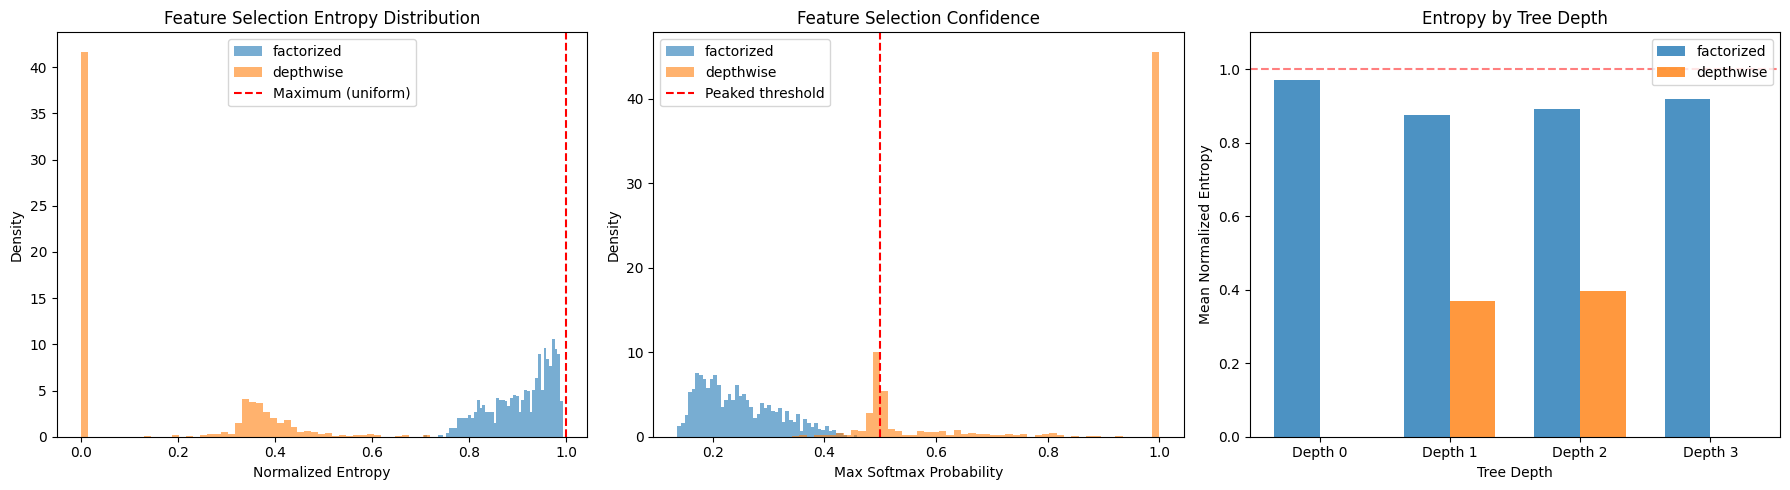

factorized: normalized_entropy=0.909, frac_peaked=0.000 -> Near-random feature selection: CONFIRMED
depthwise: normalized_entropy=0.155, frac_peaked=0.795 -> Near-random feature selection: REJECTED


In [5]:
# Visualize: entropy histograms and depth-wise breakdown
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of normalized entropy across all nodes
for variant in ["factorized", "depthwise"]:
    axes[0].hist(
        entropy_results[variant]["all_entropies"].flatten(),
        bins=50, alpha=0.6, label=variant, density=True,
    )
axes[0].axvline(x=1.0, color='red', linestyle='--', label='Maximum (uniform)')
axes[0].set_xlabel("Normalized Entropy")
axes[0].set_ylabel("Density")
axes[0].set_title("Feature Selection Entropy Distribution")
axes[0].legend()

# Histogram of max softmax probability
for variant in ["factorized", "depthwise"]:
    axes[1].hist(
        entropy_results[variant]["all_max_probs"].flatten(),
        bins=50, alpha=0.6, label=variant, density=True,
    )
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Peaked threshold')
axes[1].set_xlabel("Max Softmax Probability")
axes[1].set_ylabel("Density")
axes[1].set_title("Feature Selection Confidence")
axes[1].legend()

# Depth-wise entropy comparison
depths = sorted(entropy_results["factorized"]["depth_entropies"].keys())
x_pos = np.arange(len(depths))
width = 0.35
axes[2].bar(x_pos - width/2,
            [entropy_results["factorized"]["depth_entropies"][d] for d in depths],
            width, label="factorized", alpha=0.8)
axes[2].bar(x_pos + width/2,
            [entropy_results["depthwise"]["depth_entropies"][d] for d in depths],
            width, label="depthwise", alpha=0.8)
axes[2].set_xlabel("Tree Depth")
axes[2].set_ylabel("Mean Normalized Entropy")
axes[2].set_title("Entropy by Tree Depth")
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f"Depth {d}" for d in depths])
axes[2].axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
axes[2].legend()
axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Conclusion
for variant in ["factorized", "depthwise"]:
    ent = entropy_results[variant]["mean_normalized_entropy"]
    peaked = entropy_results[variant]["frac_peaked_gt_0.5"]
    status = "CONFIRMED" if ent > 0.8 else "REJECTED"
    print(f"{variant}: normalized_entropy={ent:.3f}, frac_peaked={peaked:.3f} -> Near-random feature selection: {status}")

Wie divers ist Feature selection? Immer gelcihe features oder unterschiedliche an jeder Node. Ein wert höher als alle anders eher unproblematisch. Innerhalb eines Trees wie unterschiedlich sind features. Innerhalb des Ensembles auch? wie unterschiedliche sind Ensembles bei Feature Selection unterschiedlicher Datensätze, bspw immer Feature 3 wird als Node 1 gewählt. Was falls nur Leaf values gelernt werden und feature selection fast random 

## Step 3: Seed Sensitivity Analysis

**Hypothesis**: Inference accuracy varies significantly across random seeds because the model trains with `seed=None` (random feature assignments per batch) but extraction uses `seed=42`.

If accuracy variance across seeds > 1%, the seed mismatch matters.

In [6]:
SEEDS = [0, 1, 7, 42, 100, 999]

seed_results = []

for dname in DIAGNOSTIC_DATASETS:
    X, y = datasets[dname]["X"], datasets[dname]["y"]
    n_classes = len(datasets[dname]["classes"])
    
    # Use a single fixed CV fold for consistency
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(iter(cv.split(X, y)))
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    
    # Precompute train stats for predict_with_grande_model
    mean = np.nanmean(X_train, axis=0)
    mean = np.nan_to_num(mean, 0)
    std = np.nanstd(X_train, axis=0, ddof=1) + 1e-6
    std[np.isnan(std)] = 1
    
    for variant in ["factorized", "depthwise"]:
        for seed in SEEDS:
            params = extract_params(variant, X_train, y_train, seed=seed)
            probs = predict_with_grande_model(
                mean, std, X_test, params, scale=True, n_classes=n_classes,
            )
            y_pred = probs.argmax(axis=1)
            acc = accuracy_score(y_test, y_pred)
            
            seed_results.append({
                "dataset": dname,
                "variant": variant,
                "seed": seed,
                "accuracy": acc,
            })

seed_df = pd.DataFrame(seed_results)

# Summarize
print("=== Accuracy by Seed ===\n")
pivot = seed_df.pivot_table(index=["dataset", "variant"], columns="seed", values="accuracy")
print(pivot.round(4).to_markdown())

print("\n=== Variance across seeds ===\n")
variance_df = seed_df.groupby(["dataset", "variant"])["accuracy"].agg(["mean", "std", "min", "max"])
variance_df["range"] = variance_df["max"] - variance_df["min"]
print(variance_df.round(4).to_markdown())

=== Accuracy by Seed ===

|                                   |      0 |      1 |      7 |     42 |    100 |    999 |
|:----------------------------------|-------:|-------:|-------:|-------:|-------:|-------:|
| ('breast-w', 'depthwise')         | 0.9571 | 0.9714 | 0.9643 | 0.9571 | 0.9714 | 0.9571 |
| ('breast-w', 'factorized')        | 0.9714 | 0.9929 | 0.9786 | 0.9786 | 0.9786 | 0.9714 |
| ('credit-approval', 'depthwise')  | 0.8623 | 0.8551 | 0.7464 | 0.8188 | 0.8768 | 0.8623 |
| ('credit-approval', 'factorized') | 0.8623 | 0.8623 | 0.8551 | 0.8623 | 0.8188 | 0.8333 |
| ('credit-g', 'depthwise')         | 0.72   | 0.715  | 0.725  | 0.725  | 0.705  | 0.725  |
| ('credit-g', 'factorized')        | 0.76   | 0.76   | 0.75   | 0.77   | 0.74   | 0.75   |

=== Variance across seeds ===

|                                   |   mean |    std |    min |    max |   range |
|:----------------------------------|-------:|-------:|-------:|-------:|--------:|
| ('breast-w', 'depthwise')         | 

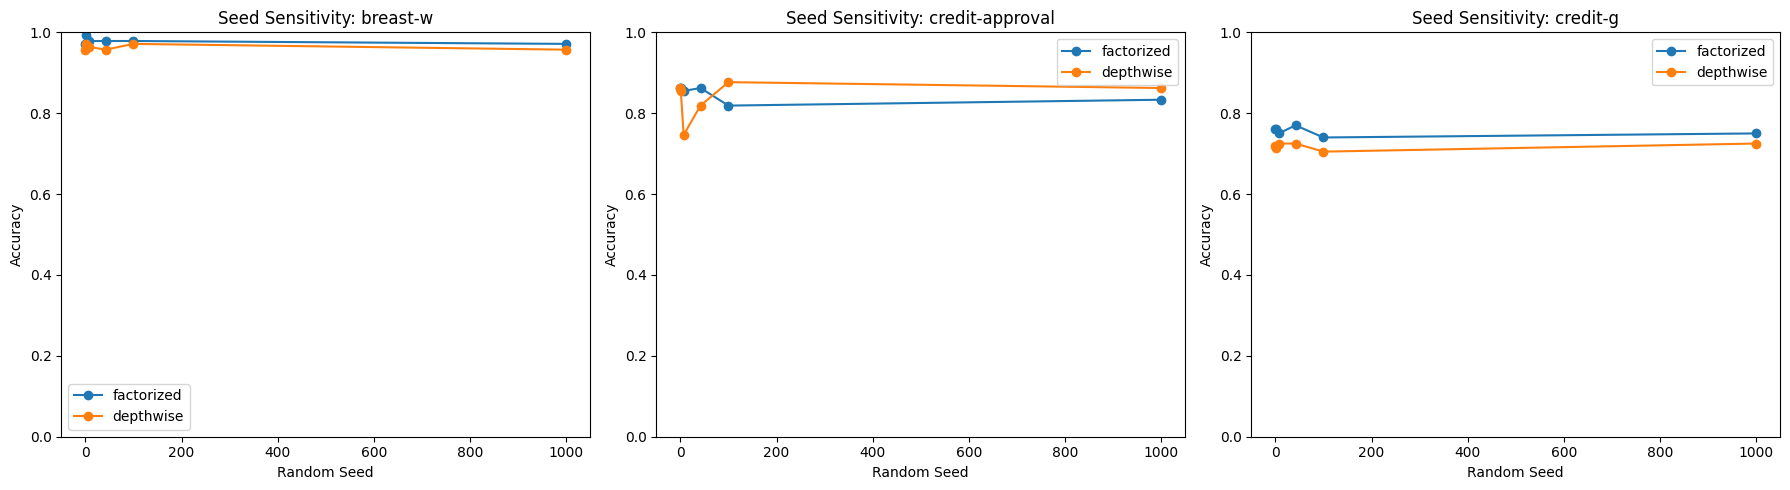


Mean accuracy range across seeds: 0.0433 -> Seed sensitivity: CONFIRMED


In [7]:
# Visualize seed sensitivity
fig, axes = plt.subplots(1, len(DIAGNOSTIC_DATASETS), figsize=(6 * len(DIAGNOSTIC_DATASETS), 5))
if len(DIAGNOSTIC_DATASETS) == 1:
    axes = [axes]

for ax, dname in zip(axes, DIAGNOSTIC_DATASETS):
    subset = seed_df[seed_df["dataset"] == dname]
    for variant in ["factorized", "depthwise"]:
        v_data = subset[subset["variant"] == variant]
        ax.plot(v_data["seed"], v_data["accuracy"], 'o-', label=variant)
    ax.set_xlabel("Random Seed")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Seed Sensitivity: {dname}")
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Conclusion
mean_range = variance_df["range"].mean()
status = "CONFIRMED" if mean_range > 0.01 else "REJECTED"
print(f"\nMean accuracy range across seeds: {mean_range:.4f} -> Seed sensitivity: {status}")

## Step 4: Split Value Distribution Analysis

**Hypothesis**: Predicted thresholds cluster near feature means, unable to make discriminative splits at distribution tails.

Measure `delta = (split_value - mu) / sigma` and check if the distribution is spread or concentrated at 0.

In [ ]:
def analyze_split_values(params, X_train, y_train, model_name, config):
    """Analyze split value distribution relative to feature statistics."""
    split_values = params["split_values"]  # (E, N, K)
    split_index_logits = params["split_index_logits"]  # (E, N, K)
    features_by_estimator = params["features_by_estimator"]  # (E, K)
    feature_mask = params["feature_mask"]  # (E, K)
    
    # Compute per-estimator feature statistics (mean, std) on the selected features
    # This mirrors what the decoder sees
    model = models[model_name]
    
    # Get the selected feature values from training data
    n_est, n_nodes, sel_vars = split_values.shape
    
    # For each estimator, compute mean/std of its selected features
    X_t = torch.as_tensor(X_train, dtype=torch.float32)
    feat_idx = torch.as_tensor(features_by_estimator, dtype=torch.long)
    f_mask = torch.as_tensor(feature_mask, dtype=torch.bool)
    
    # Gather selected features: (n_samples, n_estimators, sel_vars)
    X_selected = X_t[:, feat_idx]  # (n_samples, E, K)
    
    # Compute statistics
    valid = f_mask.unsqueeze(0) & ~torch.isnan(X_selected)
    X_clean = torch.nan_to_num(X_selected, 0.0)
    count = valid.float().sum(dim=0).clamp_min(1)
    mu = (X_clean * valid.float()).sum(dim=0) / count  # (E, K)
    centered = torch.where(valid, X_selected - mu.unsqueeze(0), torch.zeros_like(X_selected))
    sigma = torch.sqrt((centered ** 2).sum(dim=0) / (count - 1).clamp_min(1))  # (E, K)
    sigma = sigma.clamp_min(1e-3)
    
    # Compute delta = (split_value - mu) / sigma for each node
    split_t = torch.as_tensor(split_values, dtype=torch.float32)
    mu_expanded = mu.unsqueeze(1).expand_as(split_t)
    sigma_expanded = sigma.unsqueeze(1).expand_as(split_t)
    delta = (split_t - mu_expanded) / sigma_expanded
    
    # Only look at valid features
    valid_mask = f_mask.unsqueeze(1).expand_as(split_t)
    delta_valid = delta[valid_mask].numpy()
    
    # Focus on the *selected* feature per node (argmax of split_index_logits)
    logits_t = torch.as_tensor(split_index_logits, dtype=torch.float32)
    logits_masked = logits_t.masked_fill(~f_mask.unsqueeze(1), -float("inf"))
    selected_feat = logits_masked.argmax(dim=-1)  # (E, N)
    
    # Gather the delta for the selected feature at each node
    delta_selected = delta.gather(
        dim=-1, index=selected_feat.unsqueeze(-1)
    ).squeeze(-1)  # (E, N)
    delta_selected_np = delta_selected.numpy().flatten()
    
    # Fraction extreme (|delta| > 1)
    frac_extreme = (np.abs(delta_selected_np) > 1.0).mean()
    
    return {
        "delta_all": delta_valid,
        "delta_selected": delta_selected_np,
        "frac_extreme": frac_extreme,
        "mean_abs_delta": np.abs(delta_selected_np).mean(),
        "std_delta": delta_selected_np.std(),
    }


split_analysis = {}
for variant in ["factorized", "depthwise"]:
    result = analyze_split_values(
        grande_params[variant], X_train_ref, y_train_ref, variant, configs[variant]
    )
    split_analysis[variant] = result
    print(f"\n=== {variant} ===")
    print(f"  Mean |delta|: {result['mean_abs_delta']:.4f}")
    print(f"  Std delta: {result['std_delta']:.4f}")
    print(f"  Fraction extreme (|delta|>1): {result['frac_extreme']:.4f}")

Bei thresholds nur auf ausgewählte features konzentrieren und nicht auf alle 

In [ ]:
# Visualize split value distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, variant in zip(axes, ["factorized", "depthwise"]):
    delta = split_analysis[variant]["delta_selected"]
    ax.hist(delta, bins=80, alpha=0.7, density=True, color="steelblue", edgecolor="white")
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Feature mean')
    ax.axvline(x=-1, color='orange', linestyle=':', label='-1 sigma')
    ax.axvline(x=1, color='orange', linestyle=':', label='+1 sigma')
    ax.set_xlabel("Delta (split_value - mu) / sigma")
    ax.set_ylabel("Density")
    ax.set_title(f"{variant}: Split Value Distribution (selected features)")
    ax.legend()
    ax.set_xlim(-5, 5)

plt.tight_layout()
plt.show()

# Conclusion
for variant in ["factorized", "depthwise"]:
    frac = split_analysis[variant]["frac_extreme"]
    status = "CONFIRMED" if frac < 0.3 else "REJECTED"
    print(f"{variant}: frac_extreme={frac:.3f} -> Splits clustered near mean: {status}")

## Step 5: Estimator Diversity Analysis

**Hypothesis**: Estimators are near-copies due to permutation symmetry, wasting ensemble capacity.

Measure pairwise cosine similarity of split_index_logits and leaf_classes between estimators.

In [ ]:
def analyze_estimator_diversity(params):
    """Compute pairwise cosine similarity between estimators."""
    results = {}
    
    for param_name in ["split_index_logits", "leaf_classes"]:
        tensor = params[param_name]
        n_est = tensor.shape[0]
        
        # Flatten each estimator's parameters into a single vector
        flat = tensor.reshape(n_est, -1)
        flat_t = torch.as_tensor(flat, dtype=torch.float32)
        
        # Normalize
        norms = flat_t.norm(dim=1, keepdim=True).clamp_min(1e-8)
        normalized = flat_t / norms
        
        # Pairwise cosine similarity
        cos_sim = torch.mm(normalized, normalized.t())  # (E, E)
        
        # Extract upper triangle (excluding diagonal)
        mask = torch.triu(torch.ones(n_est, n_est, dtype=torch.bool), diagonal=1)
        pairwise_sims = cos_sim[mask].numpy()
        
        results[param_name] = {
            "mean_cosine_sim": pairwise_sims.mean(),
            "std_cosine_sim": pairwise_sims.std(),
            "min_cosine_sim": pairwise_sims.min(),
            "max_cosine_sim": pairwise_sims.max(),
            "pairwise_sims": pairwise_sims,
            "cos_sim_matrix": cos_sim.numpy(),
        }
    
    # Effective number of unique estimators via PCA on flattened params
    all_flat = np.concatenate([
        params["split_index_logits"].reshape(params["split_index_logits"].shape[0], -1),
        params["leaf_classes"].reshape(params["leaf_classes"].shape[0], -1),
    ], axis=1)
    
    # SVD to get explained variance
    U, S, Vt = np.linalg.svd(all_flat - all_flat.mean(axis=0), full_matrices=False)
    explained_var = S ** 2 / (S ** 2).sum()
    cum_var = np.cumsum(explained_var)
    effective_dim = (cum_var < 0.95).sum() + 1  # Number of components for 95% variance
    
    results["effective_estimators_95pct"] = int(effective_dim)
    results["singular_values"] = S
    results["explained_variance"] = explained_var
    
    return results


diversity_results = {}
for variant in ["factorized", "depthwise"]:
    result = analyze_estimator_diversity(grande_params[variant])
    diversity_results[variant] = result
    print(f"\n=== {variant} ===")
    for pname in ["split_index_logits", "leaf_classes"]:
        r = result[pname]
        print(f"  {pname}:")
        print(f"    Mean cosine sim: {r['mean_cosine_sim']:.4f}")
        print(f"    Range: [{r['min_cosine_sim']:.4f}, {r['max_cosine_sim']:.4f}]")
    print(f"  Effective estimators (95% variance): {result['effective_estimators_95pct']} / 64")

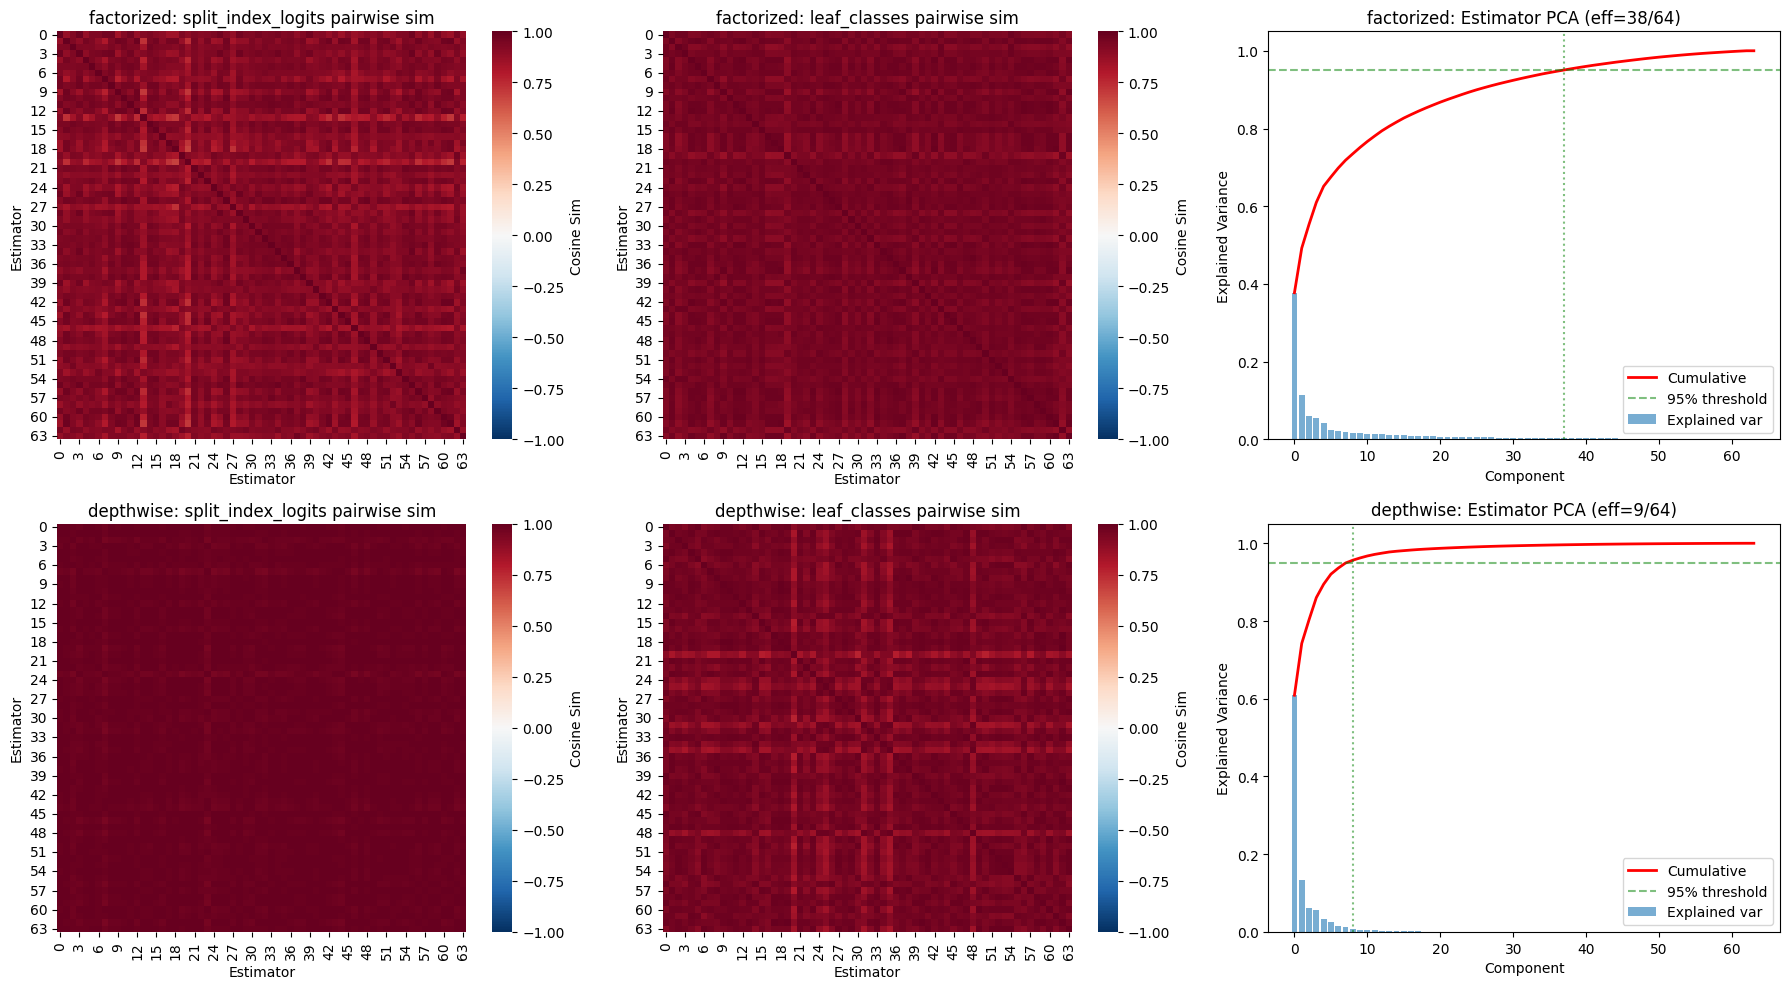

factorized: mean_cosine_sim=0.912, effective_estimators=38/64 -> Low diversity: CONFIRMED
depthwise: mean_cosine_sim=0.990, effective_estimators=9/64 -> Low diversity: CONFIRMED


In [11]:
# Visualize: cosine similarity heatmaps and singular value spectrum
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, variant in enumerate(["factorized", "depthwise"]):
    # Split index cosine similarity
    sim = diversity_results[variant]["split_index_logits"]["cos_sim_matrix"]
    sns.heatmap(sim, vmin=-1, vmax=1, cmap="RdBu_r", ax=axes[row, 0],
                cbar_kws={"label": "Cosine Sim"})
    axes[row, 0].set_title(f"{variant}: split_index_logits pairwise sim")
    axes[row, 0].set_xlabel("Estimator")
    axes[row, 0].set_ylabel("Estimator")

    # Leaf classes cosine similarity
    sim = diversity_results[variant]["leaf_classes"]["cos_sim_matrix"]
    sns.heatmap(sim, vmin=-1, vmax=1, cmap="RdBu_r", ax=axes[row, 1],
                cbar_kws={"label": "Cosine Sim"})
    axes[row, 1].set_title(f"{variant}: leaf_classes pairwise sim")
    axes[row, 1].set_xlabel("Estimator")
    axes[row, 1].set_ylabel("Estimator")

    # Singular value spectrum
    S = diversity_results[variant]["singular_values"]
    ev = diversity_results[variant]["explained_variance"]
    cum_ev = np.cumsum(ev)
    ax2 = axes[row, 2]
    ax2.bar(range(len(S)), ev, alpha=0.6, label="Explained var")
    ax2.plot(range(len(S)), cum_ev, 'r-', linewidth=2, label="Cumulative")
    ax2.axhline(y=0.95, color='green', linestyle='--', alpha=0.5, label="95% threshold")
    eff = diversity_results[variant]["effective_estimators_95pct"]
    ax2.axvline(x=eff - 1, color='green', linestyle=':', alpha=0.5)
    ax2.set_xlabel("Component")
    ax2.set_ylabel("Explained Variance")
    ax2.set_title(f"{variant}: Estimator PCA (eff={eff}/64)")
    ax2.legend()

plt.tight_layout()
plt.show()

# Conclusion
for variant in ["factorized", "depthwise"]:
    sim = diversity_results[variant]["split_index_logits"]["mean_cosine_sim"]
    eff = diversity_results[variant]["effective_estimators_95pct"]
    status = "CONFIRMED" if sim > 0.3 or eff < 32 else "REJECTED"
    print(f"{variant}: mean_cosine_sim={sim:.3f}, effective_estimators={eff}/64 -> Low diversity: {status}")

Anschauen ob Trees wirklich änhlich sind. Logging direkt einführen in Training. Initalization auch tracking. Sind Werte divers? entseht ähnlichekit während des trainings oder direkt von Initalisierung an. haben wir das gleiche auch bei den thresholds? 

Wird das gleihe feature ausgewählt? und wie wird dann der thresholds ausgewählt? Position im tree selbst ist auch relevant, evtl durch cosine bereits gehandhabt

## Step 6: Estimator Weight Analysis

**Hypothesis**: Estimator weights after softmax are near-uniform (no instance-adaptive weighting).

Measure effective ensemble size: `exp(-sum(w * log(w)))`. If close to n_estimators (64), weighting is uniform.

In [ ]:
def analyze_estimator_weights(params, X_test, model_name, config):
    """Run grande_forward and capture estimator weight distribution."""
    device = torch.device("cpu")
    n_classes = int(params["leaf_classes"].shape[-1])
    
    # Prepare test data (already scaled, but need to apply feature_rescale)
    mean = np.nanmean(X_train_ref, axis=0)
    mean = np.nan_to_num(mean, 0)
    std = np.nanstd(X_train_ref, axis=0, ddof=1) + 1e-6
    std[np.isnan(std)] = 1
    X_scaled = (X_test - mean) / std
    X_scaled = np.clip(X_scaled, -100, 100)
    X_scaled = X_scaled * params.get("feature_rescale", 1.0)
    X_t = torch.as_tensor(X_scaled, dtype=torch.float32)
    
    # Prepare parameters
    sv = torch.as_tensor(params["split_values"], dtype=torch.float32).unsqueeze(0)
    si = torch.as_tensor(params["split_index_logits"], dtype=torch.float32).unsqueeze(0)
    ew = torch.as_tensor(params["estimator_weights"], dtype=torch.float32).unsqueeze(0)
    lc = torch.as_tensor(params["leaf_classes"], dtype=torch.float32).unsqueeze(0)
    fbe = torch.as_tensor(params["features_by_estimator"], dtype=torch.long).unsqueeze(0)
    fm = torch.as_tensor(params["feature_mask"], dtype=torch.bool).unsqueeze(0)
    pil = torch.as_tensor(params["path_identifier_list"], dtype=torch.long)
    inil = torch.as_tensor(params["internal_node_index_list"], dtype=torch.long)
    
    # We need to hook into grande_forward to capture estimator_weights_softmax
    # Re-implement the relevant portion
    from ticl.models.grande_core import gather_estimator_features, one_hot_argmax
    
    x = X_t.unsqueeze(1)  # (n_test, 1, n_features)
    x_local = gather_estimator_features(x, fbe)
    nan_mask = torch.isnan(x_local)
    x_local = torch.nan_to_num(x_local, nan=0.0)
    
    logits = si.masked_fill(~fm.unsqueeze(2), -float("inf"))
    split_hard = one_hot_argmax(logits, dim=-1).float()
    
    s1_sum = torch.einsum("beik,beik->bei", sv, split_hard)
    s2_sum = torch.einsum("sbek,beik->sbei", x_local, split_hard)
    
    node_soft = (F.softsign(s1_sum.unsqueeze(0) - s2_sum) + 1) / 2
    node_hard = torch.round(node_soft)
    node_result = node_hard  # inference mode, no ST
    
    selected_nodes = node_result[..., inil]
    left = selected_nodes
    right = 1.0 - selected_nodes
    
    path_ids = pil.float()
    path_probs = torch.prod(
        ((1.0 - path_ids) * left + path_ids * right), dim=-1
    )  # (n_test, 1, E, n_leaves)
    
    # Estimator weights: (batch, E, n_leaves) dotted with path_probs
    estimator_weights_leaf = torch.einsum(
        "bel,sbel->sbe", ew, path_probs
    )  # (n_test, 1, E)
    estimator_weights_softmax = F.softmax(estimator_weights_leaf, dim=-1)  # (n_test, 1, E)
    
    # Squeeze batch dim
    w = estimator_weights_softmax.squeeze(1).detach().numpy()  # (n_test, E)
    
    # Effective ensemble size per sample
    w_safe = np.clip(w, 1e-10, None)
    effective_size = np.exp(-(w_safe * np.log(w_safe)).sum(axis=1))
    
    return {
        "weights": w,
        "effective_size": effective_size,
        "mean_effective_size": effective_size.mean(),
        "std_effective_size": effective_size.std(),
        "mean_max_weight": w.max(axis=1).mean(),
        "mean_weight_entropy": -(w_safe * np.log(w_safe)).sum(axis=1).mean(),
    }


weight_results = {}
for variant in ["factorized", "depthwise"]:
    result = analyze_estimator_weights(
        grande_params[variant], X_test_ref, variant, configs[variant]
    )
    weight_results[variant] = result
    n_est = grande_params[variant]["estimator_weights"].shape[0]
    print(f"\n=== {variant} ===")
    print(f"  Mean effective ensemble size: {result['mean_effective_size']:.2f} / {n_est}")
    print(f"  Std effective ensemble size: {result['std_effective_size']:.2f}")
    print(f"  Mean max weight: {result['mean_max_weight']:.4f}")

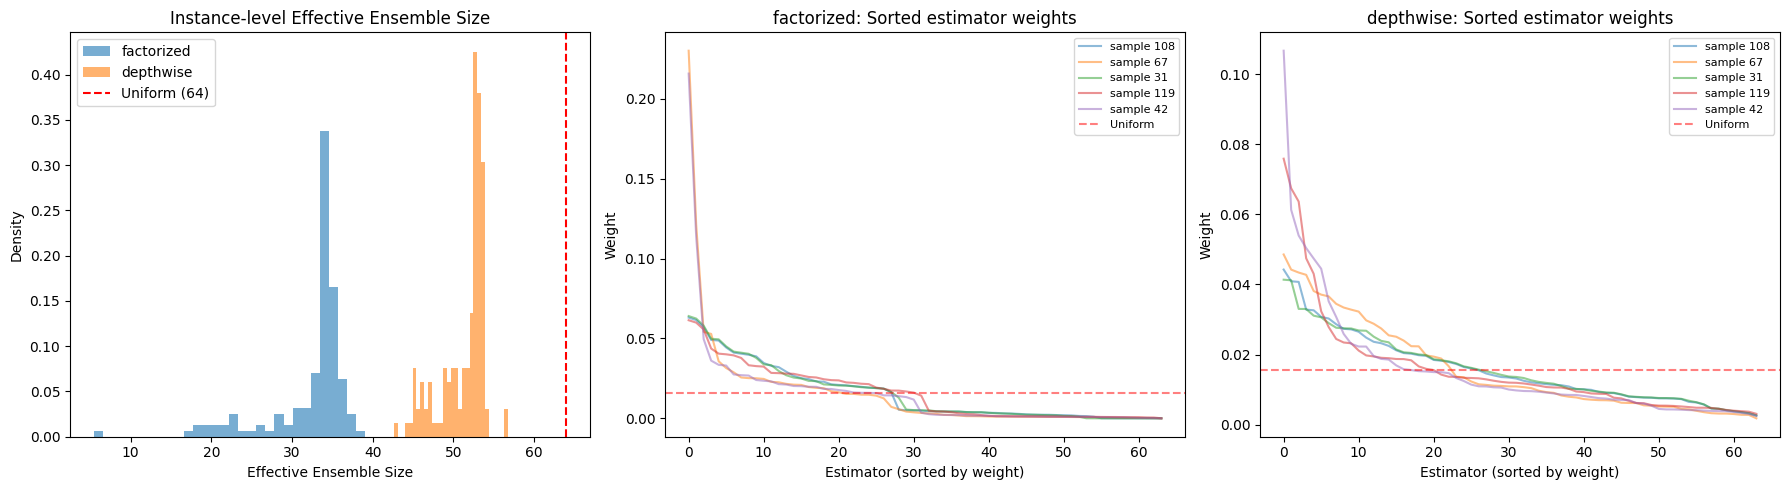

factorized: effective_size=32.2/64 -> Near-uniform weighting: REJECTED
depthwise: effective_size=51.3/64 -> Near-uniform weighting: CONFIRMED


In [13]:
# Visualize estimator weight distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Effective size histogram
for variant in ["factorized", "depthwise"]:
    axes[0].hist(weight_results[variant]["effective_size"], bins=30, alpha=0.6,
                 label=variant, density=True)
n_est = grande_params["factorized"]["estimator_weights"].shape[0]
axes[0].axvline(x=n_est, color='red', linestyle='--', label=f'Uniform ({n_est})')
axes[0].set_xlabel("Effective Ensemble Size")
axes[0].set_ylabel("Density")
axes[0].set_title("Instance-level Effective Ensemble Size")
axes[0].legend()

# Weight distribution for a sample of test instances
for ax_idx, variant in enumerate(["factorized", "depthwise"]):
    w = weight_results[variant]["weights"]
    # Show weights for 5 random test samples
    sample_idx = np.random.RandomState(42).choice(len(w), min(5, len(w)), replace=False)
    for i, si in enumerate(sample_idx):
        axes[1 + ax_idx].plot(sorted(w[si], reverse=True), alpha=0.5, label=f"sample {si}")
    axes[1 + ax_idx].axhline(y=1/n_est, color='red', linestyle='--', alpha=0.5, label='Uniform')
    axes[1 + ax_idx].set_xlabel("Estimator (sorted by weight)")
    axes[1 + ax_idx].set_ylabel("Weight")
    axes[1 + ax_idx].set_title(f"{variant}: Sorted estimator weights")
    axes[1 + ax_idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Conclusion
for variant in ["factorized", "depthwise"]:
    eff = weight_results[variant]["mean_effective_size"]
    status = "CONFIRMED" if eff > 0.8 * n_est else "REJECTED"
    print(f"{variant}: effective_size={eff:.1f}/{n_est} -> Near-uniform weighting: {status}")

relativ irrelvant wenn trees diverse sind 

## Step 7: Temperature Sweep

**Hypothesis**: Leaf class logits have wrong scale, causing miscalibration that hurts F1 > ROC AUC.

Sweep inference temperature and find the optimal value for accuracy/F1.

In [14]:
TEMPERATURES = [0.1, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 5.0]

def predict_with_temperature(params, X_test, mean, std, n_classes, temperature):
    """Run grande_forward with a custom temperature for final softmax."""
    device = torch.device("cpu")
    X = torch.as_tensor(X_test, dtype=torch.float32)
    X = (X - torch.as_tensor(mean, dtype=torch.float32)) / torch.as_tensor(std, dtype=torch.float32)
    X = torch.clamp(X, -100, 100)
    X = X * params.get("feature_rescale", 1.0)

    logits = grande_forward(
        x=X.unsqueeze(1),
        split_values=torch.as_tensor(params["split_values"], dtype=torch.float32).unsqueeze(0),
        split_index_logits=torch.as_tensor(params["split_index_logits"], dtype=torch.float32).unsqueeze(0),
        estimator_weights=torch.as_tensor(params["estimator_weights"], dtype=torch.float32).unsqueeze(0),
        leaf_classes=torch.as_tensor(params["leaf_classes"], dtype=torch.float32).unsqueeze(0),
        features_by_estimator=torch.as_tensor(params["features_by_estimator"], dtype=torch.long).unsqueeze(0),
        feature_mask=torch.as_tensor(params["feature_mask"], dtype=torch.bool).unsqueeze(0),
        path_identifier_list=torch.as_tensor(params["path_identifier_list"], dtype=torch.long),
        internal_node_index_list=torch.as_tensor(params["internal_node_index_list"], dtype=torch.long),
        training=False, dropout=0.0,
        missing_values=params.get("missing_values", True),
        straight_through=False,
    ).squeeze(1)

    if logits.shape[1] == 1 and n_classes == 2:
        logits = torch.cat([-logits, logits], dim=1)
    elif n_classes is not None:
        logits = logits[:, :n_classes]

    probs = F.softmax(logits / temperature, dim=1)
    return probs.detach().numpy()


temp_results = []

for dname in DIAGNOSTIC_DATASETS:
    X, y = datasets[dname]["X"], datasets[dname]["y"]
    n_classes = len(datasets[dname]["classes"])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(iter(cv.split(X, y)))
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    mean = np.nan_to_num(np.nanmean(X_train, axis=0), 0)
    std = np.nanstd(X_train, axis=0, ddof=1) + 1e-6
    std[np.isnan(std)] = 1

    for variant in ["factorized", "depthwise"]:
        params = extract_params(variant, X_train, y_train, seed=42)
        for temp in TEMPERATURES:
            probs = predict_with_temperature(params, X_test, mean, std, n_classes, temp)
            y_pred = probs.argmax(axis=1)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
            try:
                if n_classes == 2:
                    auc = roc_auc_score(y_test, probs[:, 1])
                else:
                    auc = roc_auc_score(y_test, probs, multi_class='ovr')
            except ValueError:
                auc = np.nan

            temp_results.append({
                "dataset": dname, "variant": variant, "temperature": temp,
                "accuracy": acc, "f1": f1, "roc_auc": auc,
            })

temp_df = pd.DataFrame(temp_results)

# Show summary
print("=== Temperature Sweep Results ===\n")
for variant in ["factorized", "depthwise"]:
    subset = temp_df[temp_df["variant"] == variant]
    pivot = subset.pivot_table(index="temperature", columns="dataset", values="accuracy")
    print(f"\n{variant} - Accuracy:")
    print(pivot.round(4).to_markdown())
    
    # Find best temperature per dataset
    best = subset.loc[subset.groupby("dataset")["accuracy"].idxmax()][["dataset", "temperature", "accuracy"]]
    print(f"\nBest temperatures: {best.to_dict('records')}")

=== Temperature Sweep Results ===


factorized - Accuracy:
|   temperature |   breast-w |   credit-approval |   credit-g |
|--------------:|-----------:|------------------:|-----------:|
|           0.1 |     0.9786 |            0.8623 |       0.77 |
|           0.3 |     0.9786 |            0.8623 |       0.77 |
|           0.5 |     0.9786 |            0.8623 |       0.77 |
|           0.8 |     0.9786 |            0.8623 |       0.77 |
|           1   |     0.9786 |            0.8623 |       0.77 |
|           1.5 |     0.9786 |            0.8623 |       0.77 |
|           2   |     0.9786 |            0.8623 |       0.77 |
|           5   |     0.9786 |            0.8623 |       0.77 |

Best temperatures: [{'dataset': 'breast-w', 'temperature': 0.1, 'accuracy': 0.9785714285714285}, {'dataset': 'credit-approval', 'temperature': 0.1, 'accuracy': 0.8623188405797102}, {'dataset': 'credit-g', 'temperature': 0.1, 'accuracy': 0.77}]

depthwise - Accuracy:
|   temperature |   breast-w |   

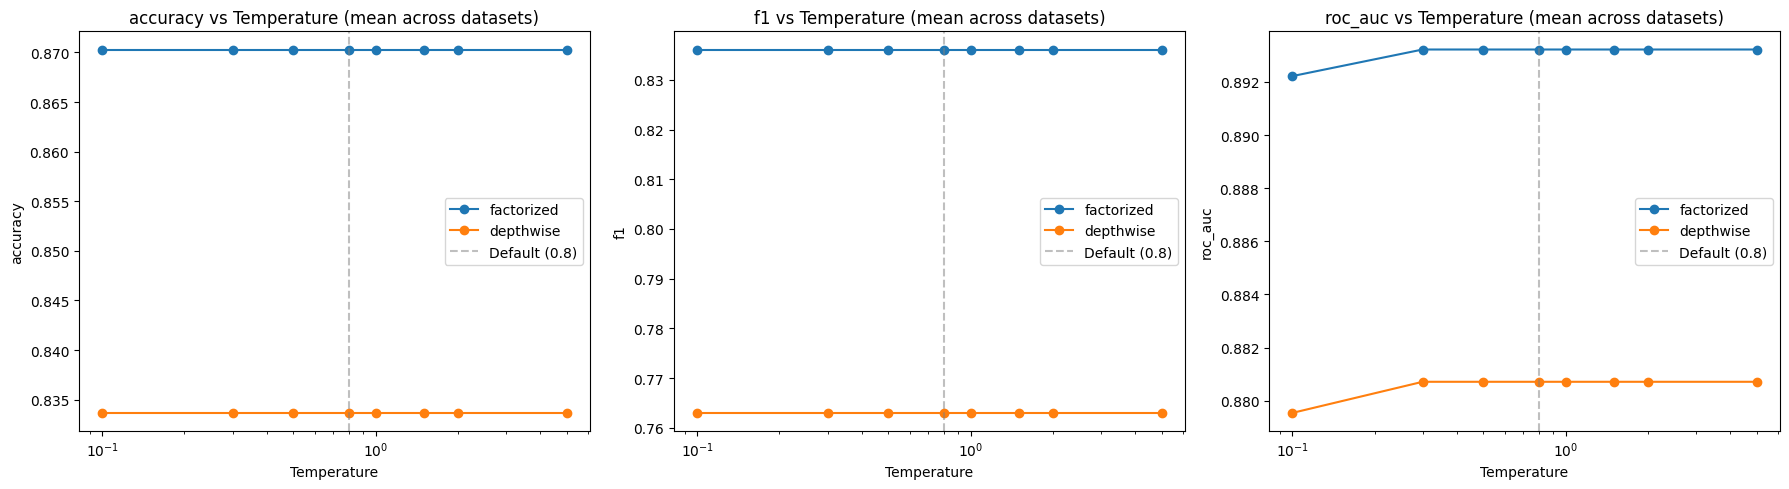

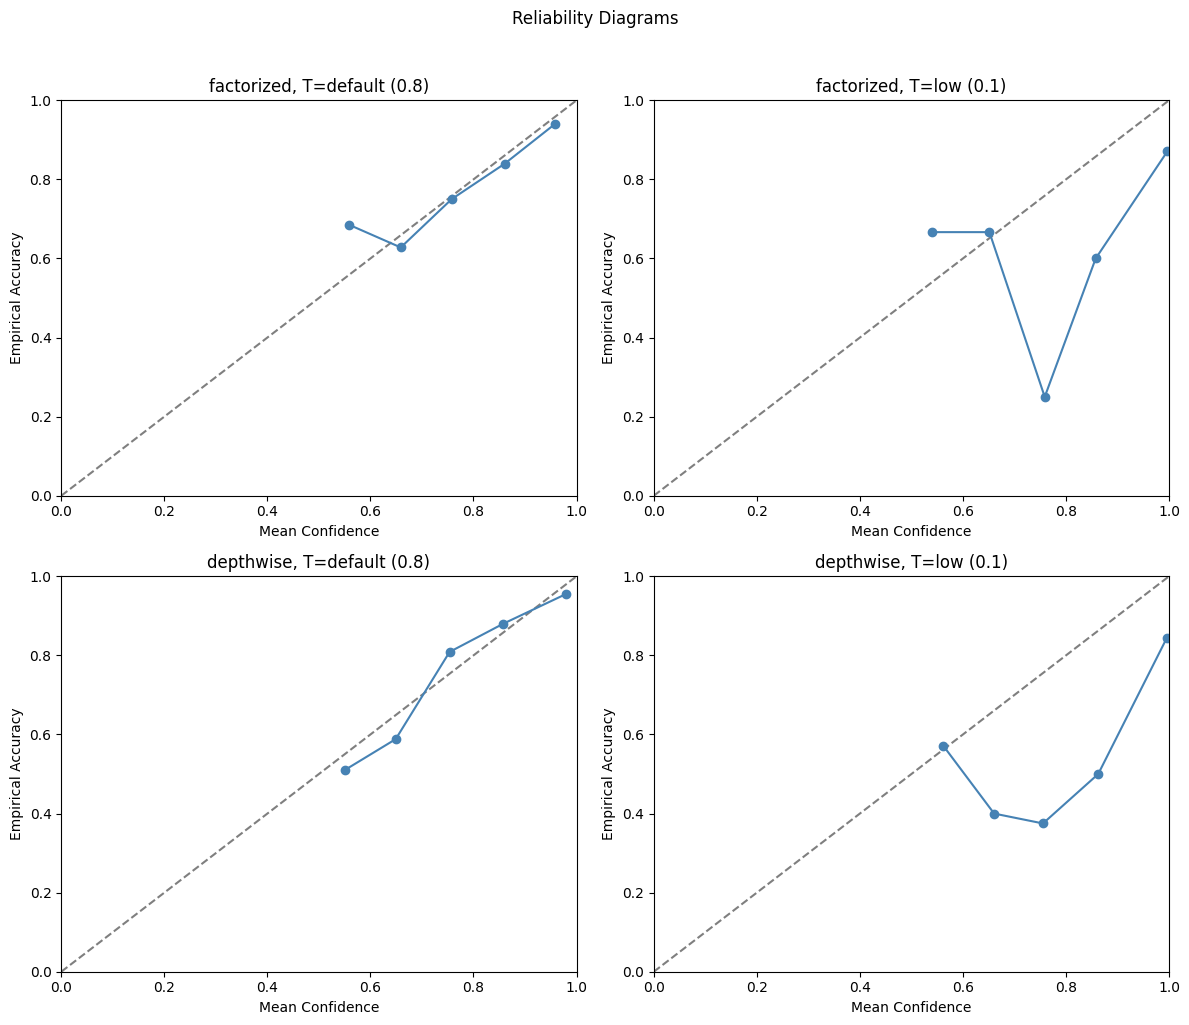

factorized: default_acc=0.8703, best_acc=0.8703 (T=0.1), delta=+0.0000 -> Miscalibration: REJECTED
depthwise: default_acc=0.8337, best_acc=0.8337 (T=0.1), delta=+0.0000 -> Miscalibration: REJECTED


In [15]:
# Visualize temperature sweep
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ["accuracy", "f1", "roc_auc"]

for ax, metric in zip(axes, metrics_to_plot):
    for variant in ["factorized", "depthwise"]:
        subset = temp_df[temp_df["variant"] == variant]
        mean_by_temp = subset.groupby("temperature")[metric].mean()
        ax.plot(mean_by_temp.index, mean_by_temp.values, 'o-', label=variant)
    ax.axvline(x=0.8, color='gray', linestyle='--', alpha=0.5, label='Default (0.8)')
    ax.set_xlabel("Temperature")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs Temperature (mean across datasets)")
    ax.legend()
    ax.set_xscale('log')

plt.tight_layout()
plt.show()

# Reliability diagrams at default and best temperature
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row, variant in enumerate(["factorized", "depthwise"]):
    for col, temp_label in enumerate(["default (0.8)", "low (0.1)"]):
        temp = 0.8 if col == 0 else 0.1
        ax = axes[row, col]

        all_confs, all_correct = [], []
        for dname in DIAGNOSTIC_DATASETS:
            X, y = datasets[dname]["X"], datasets[dname]["y"]
            n_classes = len(datasets[dname]["classes"])
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            train_idx, test_idx = next(iter(cv.split(X, y)))
            X_train, y_train = X[train_idx], y[train_idx]
            X_test, y_test = X[test_idx], y[test_idx]
            mean = np.nan_to_num(np.nanmean(X_train, axis=0), 0)
            std_vals = np.nanstd(X_train, axis=0, ddof=1) + 1e-6
            std_vals[np.isnan(std_vals)] = 1
            params = extract_params(variant, X_train, y_train, seed=42)
            probs = predict_with_temperature(params, X_test, mean, std_vals, n_classes, temp)
            confs = probs.max(axis=1)
            correct = (probs.argmax(axis=1) == y_test).astype(float)
            all_confs.extend(confs)
            all_correct.extend(correct)

        all_confs = np.array(all_confs)
        all_correct = np.array(all_correct)
        bins = np.linspace(0, 1, 11)
        bin_idx = np.digitize(all_confs, bins) - 1
        bin_idx = np.clip(bin_idx, 0, len(bins) - 2)

        bin_means = []
        bin_accs = []
        for b in range(len(bins) - 1):
            mask = bin_idx == b
            if mask.sum() > 0:
                bin_means.append(all_confs[mask].mean())
                bin_accs.append(all_correct[mask].mean())

        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.plot(bin_means, bin_accs, 'o-', color='steelblue')
        ax.set_xlabel("Mean Confidence")
        ax.set_ylabel("Empirical Accuracy")
        ax.set_title(f"{variant}, T={temp_label}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

plt.suptitle("Reliability Diagrams", y=1.02)
plt.tight_layout()
plt.show()

# Conclusion
for variant in ["factorized", "depthwise"]:
    subset = temp_df[temp_df["variant"] == variant]
    default_acc = subset[subset["temperature"] == 0.8]["accuracy"].mean()
    best_temp = subset.groupby("temperature")["accuracy"].mean().idxmax()
    best_acc = subset.groupby("temperature")["accuracy"].mean().max()
    delta = best_acc - default_acc
    status = "CONFIRMED" if delta > 0.01 else "REJECTED"
    print(f"{variant}: default_acc={default_acc:.4f}, best_acc={best_acc:.4f} (T={best_temp}), delta={delta:+.4f} -> Miscalibration: {status}")

## Step 8: Depth-wise Gradient Flow Verification

**Hypothesis**: Deep nodes (depth 3-4) receive vanishing gradients and their parameters are near-random.

If shallow nodes have lower entropy (more peaked) than deep ones, gradient vanishing is confirmed. This was already partially measured in Step 2 (depth-wise entropy). Here we add split_value variance by depth.

In [16]:
def analyze_depth_gradient_proxy(params):
    """Analyze parameter statistics by depth as proxy for gradient flow."""
    split_values = torch.as_tensor(params["split_values"], dtype=torch.float32)
    split_index_logits = torch.as_tensor(params["split_index_logits"], dtype=torch.float32)
    feature_mask = torch.as_tensor(params["feature_mask"], dtype=torch.bool)
    
    n_est, n_nodes, sel_vars = split_values.shape
    tree_depth = int(np.log2(n_nodes + 1))
    
    depth_stats = {}
    for d in range(tree_depth):
        start = 2**d - 1
        end = 2**(d+1) - 1
        
        # Split value variance at this depth
        sv_depth = split_values[:, start:end, :]  # (E, nodes_at_d, K)
        sv_var = sv_depth.var().item()
        sv_range = (sv_depth.max() - sv_depth.min()).item()
        
        # Split index logit magnitude at this depth
        si_depth = split_index_logits[:, start:end, :]
        si_logit_std = si_depth.std().item()
        si_logit_range = (si_depth.max() - si_depth.min()).item()
        
        # Max logit magnitude (how "decided" the feature selection is)
        logits_masked = si_depth.masked_fill(~feature_mask.unsqueeze(1), -float("inf"))
        probs = F.softmax(logits_masked, dim=-1)
        max_prob = probs.max(dim=-1).values
        
        depth_stats[d] = {
            "split_value_var": sv_var,
            "split_value_range": sv_range,
            "split_index_logit_std": si_logit_std,
            "split_index_logit_range": si_logit_range,
            "mean_max_feature_prob": max_prob.mean().item(),
            "entropy": entropy_results.get(
                list(entropy_results.keys())[0], {}
            ).get("depth_entropies", {}).get(d, np.nan),
        }
    
    return depth_stats


depth_results = {}
for variant in ["factorized", "depthwise"]:
    depth_stats = analyze_depth_gradient_proxy(grande_params[variant])
    depth_results[variant] = depth_stats
    # Use entropy from step 2
    for d in depth_stats:
        depth_stats[d]["entropy"] = entropy_results[variant]["depth_entropies"][d]
    print(f"\n=== {variant} ===")
    for d, stats in depth_stats.items():
        print(f"  Depth {d}: entropy={stats['entropy']:.4f}, "
              f"sv_var={stats['split_value_var']:.4f}, "
              f"si_logit_std={stats['split_index_logit_std']:.4f}, "
              f"max_feat_prob={stats['mean_max_feature_prob']:.4f}")


=== factorized ===
  Depth 0: entropy=0.9697, sv_var=164.9164, si_logit_std=0.6699, max_feat_prob=0.1840
  Depth 1: entropy=0.8759, sv_var=66.0638, si_logit_std=0.9812, max_feat_prob=0.2853
  Depth 2: entropy=0.8922, sv_var=56.4875, si_logit_std=0.9611, max_feat_prob=0.2629
  Depth 3: entropy=0.9174, sv_var=232.2638, si_logit_std=0.8906, max_feat_prob=0.2364

=== depthwise ===
  Depth 0: entropy=0.0001, sv_var=90.5488, si_logit_std=8.3918, max_feat_prob=1.0000
  Depth 1: entropy=0.3686, sv_var=101.3802, si_logit_std=5.1614, max_feat_prob=0.6317
  Depth 2: entropy=0.3969, sv_var=180.5415, si_logit_std=2.3128, max_feat_prob=0.4890
  Depth 3: entropy=0.0000, sv_var=23.4881, si_logit_std=11.8308, max_feat_prob=1.0000


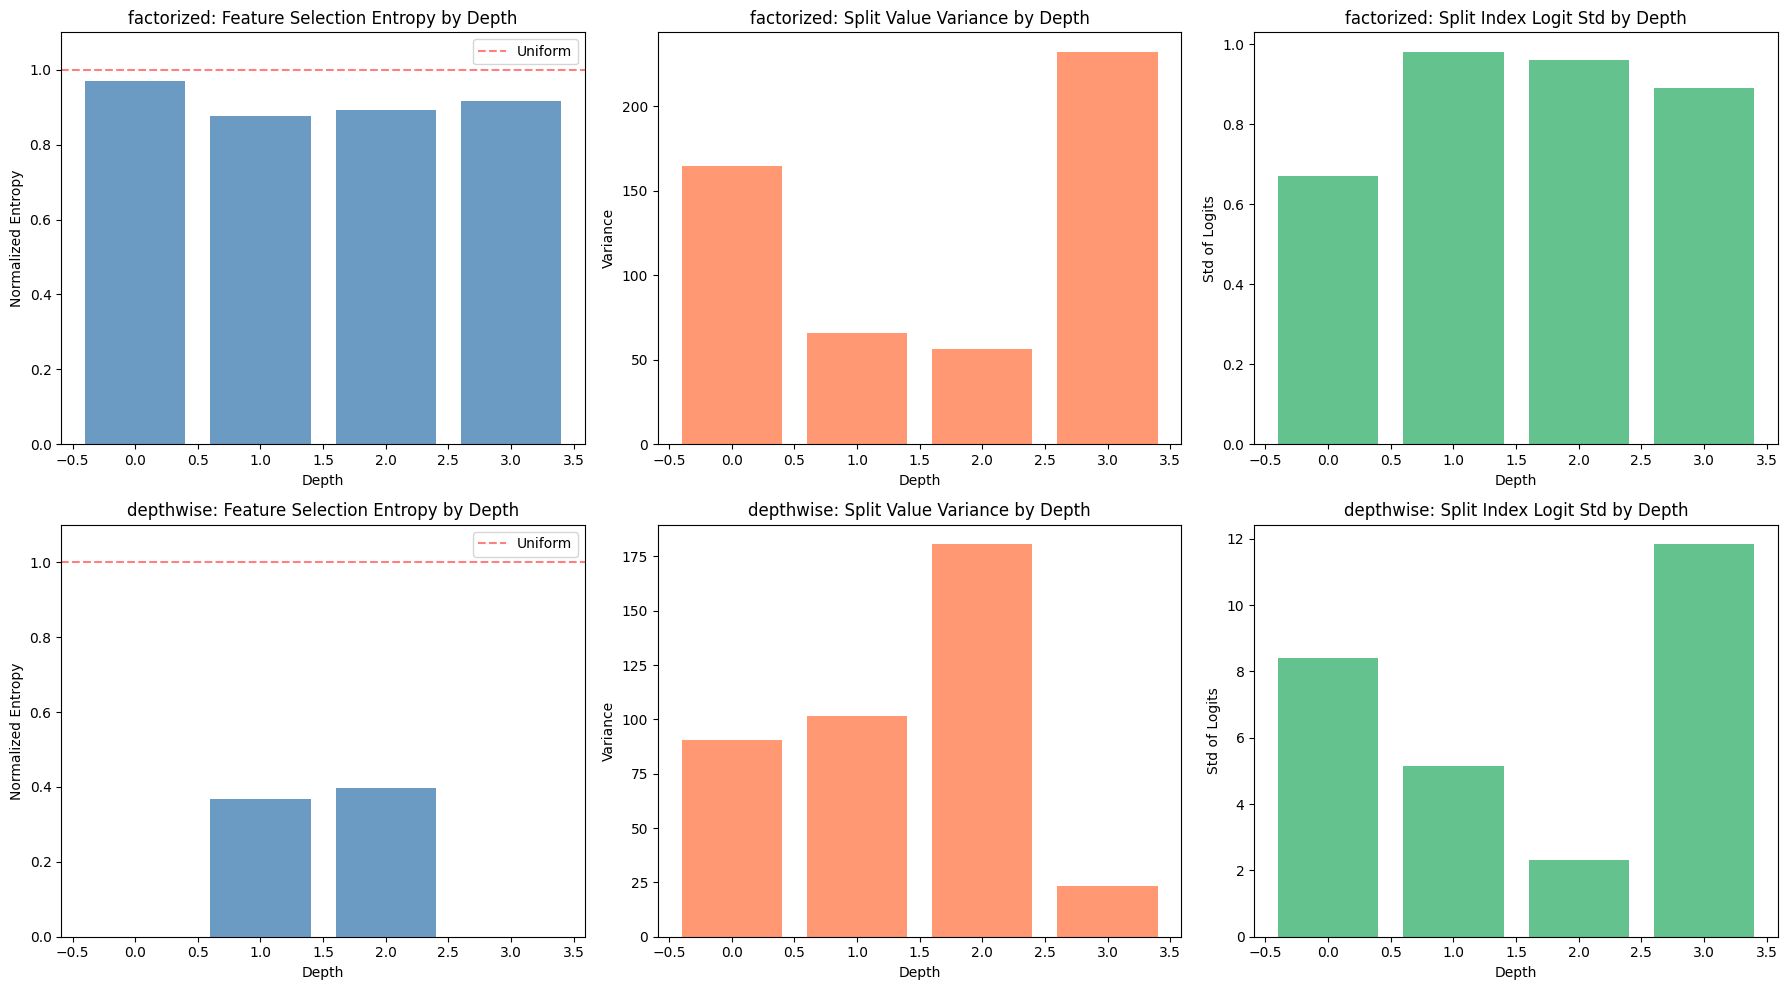

factorized: shallow_entropy=0.9697, deep_entropy=0.9174, gradient=-0.0523 -> Depth-dependent degradation: REJECTED
depthwise: shallow_entropy=0.0001, deep_entropy=0.0000, gradient=-0.0001 -> Depth-dependent degradation: REJECTED


In [17]:
# Visualize depth-wise statistics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, variant in enumerate(["factorized", "depthwise"]):
    ds = depth_results[variant]
    depths = sorted(ds.keys())
    
    # Entropy by depth
    axes[row, 0].bar(depths, [ds[d]["entropy"] for d in depths], color="steelblue", alpha=0.8)
    axes[row, 0].set_xlabel("Depth")
    axes[row, 0].set_ylabel("Normalized Entropy")
    axes[row, 0].set_title(f"{variant}: Feature Selection Entropy by Depth")
    axes[row, 0].set_ylim(0, 1.1)
    axes[row, 0].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Uniform')
    axes[row, 0].legend()
    
    # Split value variance by depth
    axes[row, 1].bar(depths, [ds[d]["split_value_var"] for d in depths], color="coral", alpha=0.8)
    axes[row, 1].set_xlabel("Depth")
    axes[row, 1].set_ylabel("Variance")
    axes[row, 1].set_title(f"{variant}: Split Value Variance by Depth")
    
    # Split index logit std by depth
    axes[row, 2].bar(depths, [ds[d]["split_index_logit_std"] for d in depths], color="mediumseagreen", alpha=0.8)
    axes[row, 2].set_xlabel("Depth")
    axes[row, 2].set_ylabel("Std of Logits")
    axes[row, 2].set_title(f"{variant}: Split Index Logit Std by Depth")

plt.tight_layout()
plt.show()

# Conclusion
for variant in ["factorized", "depthwise"]:
    ds = depth_results[variant]
    shallow_ent = ds[0]["entropy"]
    deep_ent = ds[max(ds.keys())]["entropy"]
    ent_gradient = deep_ent - shallow_ent
    status = "CONFIRMED" if ent_gradient > 0.02 else "REJECTED"
    print(f"{variant}: shallow_entropy={shallow_ent:.4f}, deep_entropy={deep_ent:.4f}, "
          f"gradient={ent_gradient:+.4f} -> Depth-dependent degradation: {status}")

## Summary: Ranked Root Causes

In [ ]:
# Compile all findings into a summary table
findings = []

for variant in ["factorized", "depthwise"]:
    # Step 2: Feature selection entropy
    ent = entropy_results[variant]["mean_normalized_entropy"]
    findings.append({
        "Variant": variant,
        "Hypothesis": "Near-random feature selection",
        "Metric": f"normalized_entropy={ent:.3f}",
        "Status": "CONFIRMED" if ent > 0.8 else "REJECTED",
        "Step": 2,
    })
    
    # Step 3: Seed sensitivity
    if variant in variance_df.index.get_level_values(1):
        v_range = variance_df.xs(variant, level=1)["range"].mean()
    else:
        v_range = seed_df[seed_df["variant"] == variant].groupby("dataset")["accuracy"].apply(
            lambda x: x.max() - x.min()
        ).mean()
    findings.append({
        "Variant": variant,
        "Hypothesis": "Seed mismatch (train vs inference)",
        "Metric": f"acc_range={v_range:.4f}",
        "Status": "CONFIRMED" if v_range > 0.01 else "REJECTED",
        "Step": 3,
    })
    
    # Step 4: Split value clustering
    frac = split_analysis[variant]["frac_extreme"]
    findings.append({
        "Variant": variant,
        "Hypothesis": "Splits clustered near feature mean",
        "Metric": f"frac_extreme={frac:.3f}",
        "Status": "CONFIRMED" if frac < 0.3 else "REJECTED",
        "Step": 4,
    })
    
    # Step 5: Low estimator diversity
    sim = diversity_results[variant]["split_index_logits"]["mean_cosine_sim"]
    eff = diversity_results[variant]["effective_estimators_95pct"]
    findings.append({
        "Variant": variant,
        "Hypothesis": "Low estimator diversity",
        "Metric": f"cosine_sim={sim:.3f}, eff={eff}/64",
        "Status": "CONFIRMED" if sim > 0.3 or eff < 32 else "REJECTED",
        "Step": 5,
    })
    
    # Step 6: Uniform estimator weights
    n_est_total = grande_params[variant]["estimator_weights"].shape[0]
    eff_size = weight_results[variant]["mean_effective_size"]
    findings.append({
        "Variant": variant,
        "Hypothesis": "Near-uniform estimator weights",
        "Metric": f"eff_size={eff_size:.1f}/{n_est_total}",
        "Status": "CONFIRMED" if eff_size > 0.8 * n_est_total else "REJECTED",
        "Step": 6,
    })
    
    # Step 7: Miscalibration
    subset = temp_df[temp_df["variant"] == variant]
    default_acc = subset[subset["temperature"] == 0.8]["accuracy"].mean()
    best_temp = subset.groupby("temperature")["accuracy"].mean().idxmax()
    best_acc = subset.groupby("temperature")["accuracy"].mean().max()
    delta = best_acc - default_acc
    findings.append({
        "Variant": variant,
        "Hypothesis": "Temperature miscalibration",
        "Metric": f"delta_acc={delta:+.4f}",
        "Status": "CONFIRMED" if delta > 0.01 else "REJECTED",
        "Step": 7,
    })
    
    # Step 8: Depth gradient decay
    ds = depth_results[variant]
    shallow_ent = ds[0]["entropy"]
    deep_ent = ds[max(ds.keys())]["entropy"]
    findings.append({
        "Variant": variant,
        "Hypothesis": "Gradient vanishing at deep nodes",
        "Metric": f"ent_gradient={deep_ent - shallow_ent:+.4f}",
        "Status": "CONFIRMED" if deep_ent - shallow_ent > 0.02 else "REJECTED",
        "Step": 8,
    })

findings_df = pd.DataFrame(findings)

print("=" * 80)
print("GRANDE MotherNet Diagnostic Summary")
print("=" * 80)
print()
for variant in ["factorized", "depthwise"]:
    print(f"\n### {variant} ###")
    vdf = findings_df[findings_df["Variant"] == variant].drop(columns=["Variant"])
    print(vdf.to_markdown(index=False))
    confirmed = vdf[vdf["Status"] == "CONFIRMED"]["Hypothesis"].tolist()
    if confirmed:
        print(f"\nConfirmed root causes: {', '.join(confirmed)}")
    else:
        print("\nNo hypotheses confirmed.")